In [1]:
%pip install -qU pypdf langchain-community langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [3]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file_path = "./documents/real_estate_tax.pdf"

loader = PyPDFLoader(file_path=pdf_file_path)
pages = []

async for page in loader.alazy_load():
    pages.append(page)

In [4]:
pages[35]

IndexError: list index out of range

In [5]:
%pip install -q py-zerox # zerox 라이브러리 파싱용

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [6]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
%pip install -q nest_asyncio

Note: you may need to restart the kernel to use updated packages.


In [8]:
import nest_asyncio
nest_asyncio.apply()

In [13]:
from pyzerox import zerox
import os
import json
import asyncio

### Model Setup (Use only Vision Models) Refer: https://docs.litellm.ai/docs/providers ###

## placeholder for additional model kwargs which might be required for some models
kwargs = {}

## system prompt to use for the vision model
custom_system_prompt = None

# to override
# custom_system_prompt = "For the below PDF page, do something..something..." ## example

###################### Example for OpenAI ######################
model = "gpt-4o" ## openai model
os.environ["OPENAI_API_KEY"] ## your-api-key


# Define main async entrypoint
async def main():
    file_path = "./documents/real_estate_tax.pdf" ## local filepath and file URL supported

    ## process only some pages or all
    select_pages = None ## None for all, but could be int or list(int) page numbers (1 indexed)

    output_dir = "./document" ## directory to save the consolidated markdown file
    result = await zerox(file_path=file_path, model=model, output_dir=output_dir,
                        custom_system_prompt=custom_system_prompt,select_pages=select_pages, **kwargs)
    return result


# run the main function:
result = asyncio.run(main())

# print markdown result
print(result)

ZeroxOutput(completion_time=17862.145, file_name='real_estate_tax', input_tokens=11470, output_tokens=13225, pages=[Page(content='종합부동산세법\n====================\n[시행 2026. 1. 1] [법률 제21224호, 2025. 12. 23., 일부개정]  \n재정경제부 (재산세제과) 044-215-4313\n\n제1장 총칙\n\n제1조(목적) 이 법은 고액의 부동산 보유자에 대하여 종합부동산세를 부과하여 부동산보유에 대한 조세부담의 형평성을 제고하고, 부동산의 가격안정을 도모함으로써 지방재정의 균형발전과 국민경제의 건전한 발전에 이바지함을 목적으로 한다.\n\n제2조(정의) 이 법에서 사용하는 용어의 정의는 다음 각호와 같다. <개정 2005. 12. 31., 2010. 3. 31., 2016. 1. 19., 2018. 12. 31., 2020. 6. 9., 2023. 3. 14.>\n\n1. "시ㆍ군ㆍ구"라 함은 「지방자치법」 제2조에 따른 지방자치단체인 시ㆍ군 및 자치구(이하 "시ㆍ군ㆍ구"이라 한다)를 말한다.  \n2. "시장ㆍ군수ㆍ구청장"이라 함은 지방자치단체의 장인 시장ㆍ군수 및 자치구의 구청장(이하 "시장ㆍ군수ㆍ구청장"이라 한다)을 말한다.  \n3. "주택"이라 함은 「지방세법」 제104조제3호에 의한 주택을 말한다.  \n4. "토지"라 함은 「지방세법」 제104조제1호에 따른 토지를 말한다.  \n5. "주택분 재산세"라 함은 「지방세법」 제105조 및 제107조에 따라 주택에 대하여 부과하는 재산세를 말한다.  \n6. "토지분 재산세"라 함은 「지방세법」 제105조 및 제107조에 따라 토지에 대하여 부과하는 재산세를 말한다.  \n7. 삭제<2005. 12. 31.>  \n8. "세대"라 함은 주택 또는 토지의 소유자 및 그 배우자와 그들과 생계를 같이하는 가족으로서 대통령령으로 정하는 것을 말한다.  \n9. "공시

In [14]:
%pip install -q "unstructured[md]" nltk

Note: you may need to restart the kernel to use updated packages.


In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators=['\n\n', '\n']
)

In [17]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader
from langchain_core.documents import Document

markdown_path = "./documents/real_estate_tax.md"
loader = UnstructuredMarkdownLoader(markdown_path)
document_list = loader.load_and_split(text_splitter)

In [18]:
document_list[43]

IndexError: list index out of range

In [20]:
%pip install -q markdown html2text beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [21]:
import markdown
from bs4 import BeautifulSoup

text_path = './documents/real_estate_tax.txt'

# 마크다운 파일을 읽어옵니다
with open(markdown_path, 'r', encoding='utf-8') as md_file:
    md_content = md_file.read()

# 마크다운 콘텐츠를 HTML로 변환합니다
html_content = markdown.markdown(md_content)

# HTML 콘텐츠를 파싱하여 텍스트만 추출합니다
soup = BeautifulSoup(html_content, 'html.parser')
text_content = soup.get_text()

# 추출한 텍스트를 텍스트 파일로 저장합니다
with open(text_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(text_content)

print("Markdown converted to plain text successfully!")

Markdown converted to plain text successfully!


In [22]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader(text_path)
document_list = loader.load_and_split(text_splitter)

In [ ]:
document_list[39]

In [16]:
%pip install -q langchain-chroma

Note: you may need to restart the kernel to use updated packages.


In [17]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')

In [18]:
from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)

In [19]:
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [20]:
query = '연봉 5천만원 직장인의 소득세는?'

In [21]:
retriever.invoke(query)

[Document(id='7a893f59-b8ce-4a2b-9947-a600879665cb', metadata={'source': './documents/income_tax.md'}, page_content='다. 제16조제1항제10호에 따른 직장공제회초과받환급에 대해서는 기본세율 라. 그 밖의 이자소득에 대해서는 100분의 14\n\n배당소득에 대해서는 다음과 같이 추정하는 세율 가. 제7조제1항제2호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25 나. 그 밖의 배당소득에 대해서는 100분의 14\n\n원천소득당 사업소득에 대해서는 100분의 3. 단, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클래지 사용 명 중 프로스포츠단만의 계약(계약기간이 3년 이하인 경우)을 한다는 조건에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다.\n\n근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n\n공적연금소득에 대해서는 기본세율\n\n59.제210조제3조제1항제2호관련 및 다목에 따른 연금계좌 납입액에 따른 증감지급 금액을 연금수령할 연금소득세에 대해서는 다음 각 호의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n\n가. 연금소득자와 나이에 따른 단일의 세율 나이(연금수령형태) 세율 70세 미만 100분의 5 70세 이상 100분의 3\n\n스텍스트판'),
 Document(id='ea6177bb-5a20-4d60-9951-c7a878fecec7', metadata={'source': './documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. <대통령 2

In [22]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [23]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [24]:
def retrieve(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 검색된 문서가 추가된 state를 반환합니다.
    """
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [27]:
from langchain_classic import hub
from langchain_openai import ChatOpenAI
prompt = hub.pull("rlm/rag-prompt")
llm = ChatOpenAI(model='gpt-4o')

In [28]:
def generate(state: AgentState) -> AgentState:
    """
    사용자의 질문과 검색된 문서를 기반으로 응답을 생성합니다.

    Args:
        state (AgentState): 사용자의 질문과 검색된 문서를 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 생성된 응답이 추가된 state를 반환합니다.
    """
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    rag_chain = prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.
    response = rag_chain.invoke({'question': query, 'context': context})  # 질문과 문맥을 사용하여 응답을 생성합니다.
    return {'answer': response}  # 생성된 응답을 포함한 state를 반환합니다.

In [29]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

In [30]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

In [31]:
graph = graph_builder.compile()

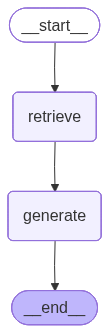

In [32]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [34]:
sequence_graph_builder.add_edge(START, 'retrieve')
sequence_graph_builder.add_edge('generate', END)

In [35]:
sequence_graph = sequence_graph_builder.compile()

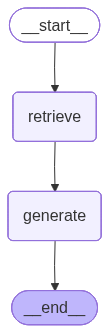

In [36]:
display(Image(sequence_graph.get_graph().draw_mermaid_png()))

In [37]:
initial_state = {'query': query}
graph.invoke(initial_state)

{'query': '연봉 5천만원 직장인의 소득세는?',
 'context': [Document(id='7a893f59-b8ce-4a2b-9947-a600879665cb', metadata={'source': './documents/income_tax.md'}, page_content='다. 제16조제1항제10호에 따른 직장공제회초과받환급에 대해서는 기본세율 라. 그 밖의 이자소득에 대해서는 100분의 14\n\n배당소득에 대해서는 다음과 같이 추정하는 세율 가. 제7조제1항제2호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25 나. 그 밖의 배당소득에 대해서는 100분의 14\n\n원천소득당 사업소득에 대해서는 100분의 3. 단, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클래지 사용 명 중 프로스포츠단만의 계약(계약기간이 3년 이하인 경우)을 한다는 조건에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다.\n\n근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n\n공적연금소득에 대해서는 기본세율\n\n59.제210조제3조제1항제2호관련 및 다목에 따른 연금계좌 납입액에 따른 증감지급 금액을 연금수령할 연금소득세에 대해서는 다음 각 호의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n\n가. 연금소득자와 나이에 따른 단일의 세율 나이(연금수령형태) 세율 70세 미만 100분의 5 70세 이상 100분의 3\n\n스텍스트판'),
  Document(id='ea6177bb-5a20-4d60-9951-c7a878fecec7', metadata={'source': './documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지